In [ ]:

!pip install nibabel scikit-learn catboost torchvision tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [ ]:
!pip install monai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 38.9 MB/s eta 0:00:00


In [ ]:
import monai
print(monai.__version__)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


1.5.2


thử làm transfer

In [ ]:
import torch
from monai.networks.nets import resnet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet.resnet10(
    spatial_dims=3,
    n_input_channels=1,
    pretrained=True,
    feed_forward=False,
    shortcut_type="B",
    bias_downsample=False
).to(device)

print(" Pretrained MedicalNet ResNet-10 loaded thành công!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


resnet_10_23dataset.pth:   0%|          | 0.00/57.5M [00:00<?, ?B/s]

✅ Pretrained MedicalNet ResNet-10 loaded thành công!


In [ ]:

import torch.nn as nn

class ResNet10_Classifier(nn.Module):
    def __init__(self, backbone, feature_shape, num_classes=3):
        super().__init__()
        self.backbone = backbone
        self.feature_shape = feature_shape

        # Tính in_features tự động
        if len(feature_shape) == 1:
            # Output đã là vector 1D: (B, features)
            in_features = feature_shape[0]
            self.pool = nn.Identity()
        elif len(feature_shape) == 4:
            # Output là 4D: (B, C, H, W) hoặc (B, C, D, H)
            in_features = feature_shape[0]
            self.pool = nn.AdaptiveAvgPool2d(1)
        elif len(feature_shape) == 5:
            # Output là 5D: (B, C, D, H, W)
            in_features = feature_shape[1]
            self.pool = nn.AdaptiveAvgPool3d(1)
        else:
            in_features = feature_shape[-1]
            self.pool = nn.Identity()

        print(f"in_features = {in_features}")

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)
        if isinstance(feat, (list, tuple)):
            feat = feat[-1]  # lấy feature cuối
        feat = self.pool(feat)
        return self.classifier(feat)


# Lấy shape thực tế từ backbone
with torch.no_grad():
    dummy   = torch.randn(2, 1, 96, 112, 96).to(device)
    feat    = model(dummy)
    if isinstance(feat, (list, tuple)):
        feat = feat[-1]
    feat_shape = feat.shape[1:]  # bỏ batch dim

print(f"Feature shape (không tính batch): {feat_shape}")

full_model = ResNet10_Classifier(model, feat_shape, num_classes=3).to(device)

# Test output
with torch.no_grad():
    out = full_model(dummy)
print(f" Output shape: {out.shape}")  # phải là (2, 3)

Feature shape (không tính batch): torch.Size([3])
in_features = 3
✅ Output shape: torch.Size([2, 3])


In [ ]:

import torch
from monai.networks.nets import resnet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet.resnet10(
    spatial_dims=3,
    n_input_channels=1,
    pretrained=True,
    feed_forward=False,
    shortcut_type="B",
    bias_downsample=False
).to(device)

# Test nhiều size input
for shape in [(2, 1, 96, 112, 96), (1, 1, 64, 64, 64)]:
    dummy = torch.randn(*shape).to(device)
    with torch.no_grad():
        out = model(dummy)
    if isinstance(out, (list, tuple)):
        print(f"Input {shape} → tuple/list len={len(out)}")
        for i, o in enumerate(out):
            print(f"  [{i}]: {o.shape}")
    else:
        print(f"Input {shape} → Output: {out.shape}")


Input (2, 1, 96, 112, 96) → Output: torch.Size([2, 512])
Input (1, 1, 64, 64, 64) → Output: torch.Size([1, 512])


In [ ]:

import torch.nn as nn

class MONAI_ResNet10_Classifier(nn.Module):
    def __init__(self, backbone, num_classes=3):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(512),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)  # (B, 512)
        return self.head(feat)


full_model = MONAI_ResNet10_Classifier(model, num_classes=3).to(device)

# Test nhanh
dummy = torch.randn(2, 1, 96, 112, 96).to(device)
with torch.no_grad():
    out = full_model(dummy)
print(f" Output shape: {out.shape}")  # (2, 3)

✅ Output shape: torch.Size([2, 3])


In [ ]:

from torch.optim.lr_scheduler import CosineAnnealingLR

class_counts = [101, 203, 97]
total        = sum(class_counts)
weights_ce   = torch.tensor([total/c for c in class_counts],
                              dtype=torch.float32).to(device)
criterion    = nn.CrossEntropyLoss(weight=weights_ce)

best_val_acc = 0
history      = {'train_loss': [], 'train_acc': [],
                'val_loss':   [], 'val_acc':   []}

def run_epoch(loader, train=True):
    full_model.train() if train else full_model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for volumes, labels in loader:
            volumes, labels = volumes.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs     = full_model(volumes)
            loss        = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total * 100


# ── PHASE 1: Freeze backbone → train head only (5 epochs) ──
print("=" * 55)
print("PHASE 1: Freeze backbone → Train head (5 epochs)")
print("=" * 55)

for param in full_model.backbone.parameters():
    param.requires_grad = False
for param in full_model.head.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in full_model.parameters() if not p.requires_grad)
print(f"Trainable : {trainable:,}")
print(f"Frozen    : {frozen:,}\n")

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, full_model.parameters()),
    lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-5)

for epoch in range(5):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(full_model.state_dict(),
                   '/content/drive/MyDrive/PBL4/best_resnet10_pretrained.pth')
        print(f"Epoch {epoch+1:2d} | Train: {t_acc:.1f}% | Val: {v_acc:.1f}% ✅ SAVED")
    else:
        print(f"Epoch {epoch+1:2d} | Train: {t_acc:.1f}% | Val: {v_acc:.1f}%")


# ── PHASE 2: Unfreeze tất cả, fine-tune (25 epochs) ──
print("\n" + "=" * 55)
print("PHASE 2: Unfreeze tất cả, Fine-tune (25 epochs)")
print("=" * 55)

for param in full_model.parameters():
    param.requires_grad = True

print(f"Trainable: {sum(p.numel() for p in full_model.parameters()):,}\n")

optimizer = torch.optim.Adam([
    {'params': full_model.backbone.parameters(), 'lr': 1e-5},  # nhỏ giữ, pretrained
    {'params': full_model.head.parameters(),     'lr': 1e-4}   # lớn hơn, học nhanh
], weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

for epoch in range(25):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(full_model.state_dict(),
                   '/content/drive/MyDrive/PBL4/best_resnet10_pretrained.pth')
        print(f"Epoch {epoch+1:2d} | Train: {t_acc:.1f}% | Val: {v_acc:.1f}%  SAVED")
    else:
        print(f"Epoch {epoch+1:2d} | Train: {t_acc:.1f}% | Val: {v_acc:.1f}%")

print(f"\n Best Val Accuracy: {best_val_acc:.1f}%")

PHASE 1: Freeze backbone → Train head (5 epochs)
Trainable : 67,075
Frozen    : 14,355,520

Epoch  1 | Train: 30.7% | Val: 35.0% ✅ SAVED
Epoch  2 | Train: 39.3% | Val: 41.7% ✅ SAVED
Epoch  3 | Train: 37.9% | Val: 48.3% ✅ SAVED
Epoch  4 | Train: 44.3% | Val: 51.7% ✅ SAVED
Epoch  5 | Train: 42.5% | Val: 48.3%

PHASE 2: Unfreeze tất cả → Fine-tune (25 epochs)
Trainable: 14,422,595

Epoch  1 | Train: 43.2% | Val: 46.7%
Epoch  2 | Train: 40.0% | Val: 33.3%
Epoch  3 | Train: 37.9% | Val: 50.0%
Epoch  4 | Train: 34.3% | Val: 38.3%
Epoch  5 | Train: 34.3% | Val: 48.3%
Epoch  6 | Train: 41.4% | Val: 46.7%
Epoch  7 | Train: 37.1% | Val: 51.7%
Epoch  8 | Train: 46.4% | Val: 48.3%
Epoch  9 | Train: 41.1% | Val: 46.7%
Epoch 10 | Train: 42.5% | Val: 40.0%
Epoch 11 | Train: 39.6% | Val: 43.3%
Epoch 12 | Train: 42.9% | Val: 46.7%
Epoch 13 | Train: 48.2% | Val: 46.7%
Epoch 14 | Train: 44.6% | Val: 45.0%
Epoch 15 | Train: 41.8% | Val: 45.0%
Epoch 16 | Train: 40.0% | Val: 45.0%
Epoch 17 | Train: 46.1% | 

KeyboardInterrupt: 

In [ ]:
# ============================================
# EXTRACT FEATURES TỪ BACKBONE (FREEZE HOÀN TOÀN)
# ============================================
import numpy as np
import pandas as pd
from tqdm import tqdm

# Freeze toàn bộ backbone
for param in full_model.backbone.parameters():
    param.requires_grad = False
full_model.eval()

def extract_features(loader):
    all_features, all_labels = [], []
    with torch.no_grad():
        for volumes, labels in tqdm(loader, desc="Extracting"):
            volumes = volumes.to(device)
            feats   = full_model.backbone(volumes)  # (B, 512)
            all_features.append(feats.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.vstack(all_features), np.array(all_labels)

print("Extracting features...")
X_train, y_train = extract_features(train_loader)
X_val,   y_val   = extract_features(val_loader)
X_test,  y_test  = extract_features(test_loader)

print(f"\nX_train: {X_train.shape}")  # (280, 512)
print(f"X_val  : {X_val.shape}")     # (60, 512)
print(f"X_test : {X_test.shape}")    # (61, 512)

Extracting features...


Extracting: 100%|██████████| 16/16 [00:04<00:00,  3.68it/s]


X_train: (280, 512)
X_val  : (60, 512)
X_test : (61, 512)


In [ ]:

# THÊM CLINICAL FEATURES (Age, Sex)

CSV_PATH = '/content/drive/MyDrive/PBL4/data/ADNI2/adni2_with_paths.csv'
df       = pd.read_csv(CSV_PATH)

LABEL_MAP = {'CN': 0, 'MCI': 1, 'AD': 2}
df['label']  = df['Group'].map(LABEL_MAP)
df['sex_bin'] = (df['Sex'] == 'M').astype(int)

# Map file sang clinical features
def get_clinical(file_list):
    age_list, sex_list = [], []
    for fname in file_list:
        img_id = fname.replace('.npy', '').split('_')[0]  # e.g. I15885
        row    = df[df['Image Data ID'] == img_id]
        if len(row) > 0:
            age_list.append(row['Age'].values[0])
            sex_list.append(row['sex_bin'].values[0])
        else:
            age_list.append(df['Age'].mean())
            sex_list.append(0)
    return np.array(age_list), np.array(sex_list)

age_train, sex_train = get_clinical(train_files)
age_val,   sex_val   = get_clinical(val_files)
age_test,  sex_test  = get_clinical(test_files)

# Normalize age
age_mean = age_train.mean()
age_std  = age_train.std()
age_train_norm = (age_train - age_mean) / age_std
age_val_norm   = (age_val   - age_mean) / age_std
age_test_norm  = (age_test  - age_mean) / age_std

# Ghép ResNet features + Age + Sex
X_train_full = np.hstack([X_train,
                           age_train_norm.reshape(-1,1),
                           sex_train.reshape(-1,1)])
X_val_full   = np.hstack([X_val,
                           age_val_norm.reshape(-1,1),
                           sex_val.reshape(-1,1)])
X_test_full  = np.hstack([X_test,
                           age_test_norm.reshape(-1,1),
                           sex_test.reshape(-1,1)])

print(f"X_train_full: {X_train_full.shape}")  # (280, 514)
print(f" Đã thêm Age + Sex vào features")

0:	learn: 0.4340909	test: 0.3093257	best: 0.3093257 (0)	total: 522ms	remaining: 4m 20s
50:	learn: 0.7649099	test: 0.4058669	best: 0.4510727 (10)	total: 16.7s	remaining: 2m 26s
100:	learn: 0.8532328	test: 0.3407947	best: 0.4510727 (10)	total: 34.4s	remaining: 2m 15s
150:	learn: 0.9178194	test: 0.3407947	best: 0.4510727 (10)	total: 50.6s	remaining: 1m 56s
200:	learn: 0.9786540	test: 0.3407947	best: 0.4510727 (10)	total: 1m 6s	remaining: 1m 38s
250:	learn: 0.9922414	test: 0.3407947	best: 0.4510727 (10)	total: 1m 22s	remaining: 1m 21s
300:	learn: 0.9941810	test: 0.3064251	best: 0.4510727 (10)	total: 1m 38s	remaining: 1m 5s
350:	learn: 1.0000000	test: 0.3064251	best: 0.4510727 (10)	total: 1m 55s	remaining: 48.9s
400:	learn: 1.0000000	test: 0.2955889	best: 0.4510727 (10)	total: 2m 12s	remaining: 32.8s
450:	learn: 1.0000000	test: 0.2846979	best: 0.4510727 (10)	total: 2m 32s	remaining: 16.6s
499:	learn: 1.0000000	test: 0.2955889	best: 0.4510727 (10)	total: 2m 48s	remaining: 0us

bestTest = 0.4

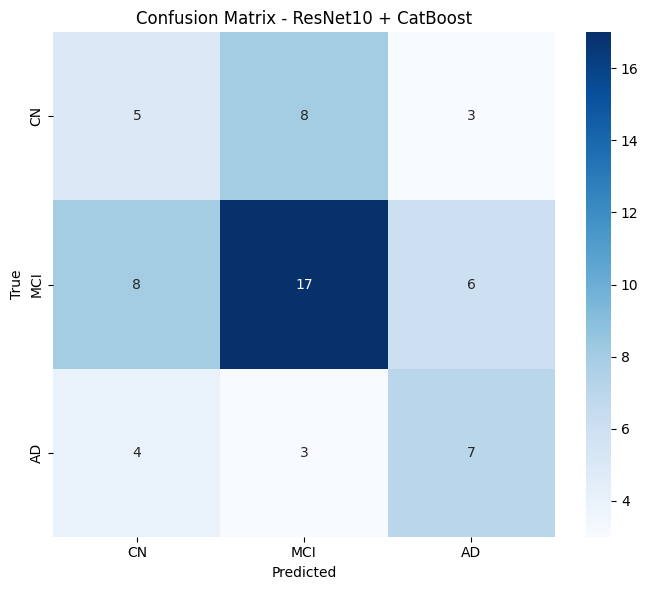

✅ Đã lưu CatBoost model


In [ ]:

# TRAIN CATBOOST TRÊN FEATURES
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Kết hợp train + val để train CatBoost
X_trainval = np.vstack([X_train_full, X_val_full])
y_trainval = np.hstack([y_train, y_val])

catboost = CatBoostClassifier(
    iterations    = 500,
    learning_rate = 0.05,
    depth         = 6,
    loss_function = 'MultiClass',
    eval_metric   = 'Accuracy',
    class_weights = [3.97, 1.98, 4.13],  # xử lý imbalanced
    random_seed   = 42,
    verbose       = 50
)

catboost.fit(
    X_trainval, y_trainval,
    eval_set=(X_test_full, y_test)
)


# ĐÁNH GIÁ
y_pred = catboost.predict(X_test_full)

print("\n" + "=" * 50)
print("KẾT QUẢ CUỐI - ResNet10 + CatBoost")
print("=" * 50)
print(classification_report(y_test, y_pred,
                             target_names=['CN', 'MCI', 'AD']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN', 'MCI', 'AD'],
            yticklabels=['CN', 'MCI', 'AD'])
plt.title('Confusion Matrix - ResNet10 + CatBoost')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PBL4/confusion_matrix_catboost.png', dpi=100)
plt.show()


catboost.save_model('/content/drive/MyDrive/PBL4/catboost_model.cbm')
print(" Đã lưu CatBoost model")


In [ ]:

# GIẢM CHIỀU FEATURES BẰNG PCA TRƯỚC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa features trước
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled   = scaler.transform(X_val_full)
X_test_scaled  = scaler.transform(X_test_full)

# PCA giữ 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Trước PCA : {X_train_full.shape[1]} features")
print(f"Sau PCA   : {X_train_pca.shape[1]} features")
print(f"Variance  : {pca.explained_variance_ratio_.sum():.3f}")

X_trainval_pca = np.vstack([X_train_pca, X_val_pca])
y_trainval     = np.hstack([y_train, y_val])

Trước PCA : 514 features
Sau PCA   : 5 features
Variance  : 0.959


0:	learn: 0.4222962	test: 0.3705670	best: 0.3705670 (0)	total: 5.15ms	remaining: 5.14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4258428183
bestIteration = 14

Shrink model to first 15 iterations.

KẾT QUẢ - ResNet10 + PCA + CatBoost
              precision    recall  f1-score   support

          CN       0.36      0.50      0.42        16
         MCI       0.59      0.55      0.57        31
          AD       0.30      0.21      0.25        14

    accuracy                           0.46        61
   macro avg       0.42      0.42      0.41        61
weighted avg       0.46      0.46      0.46        61



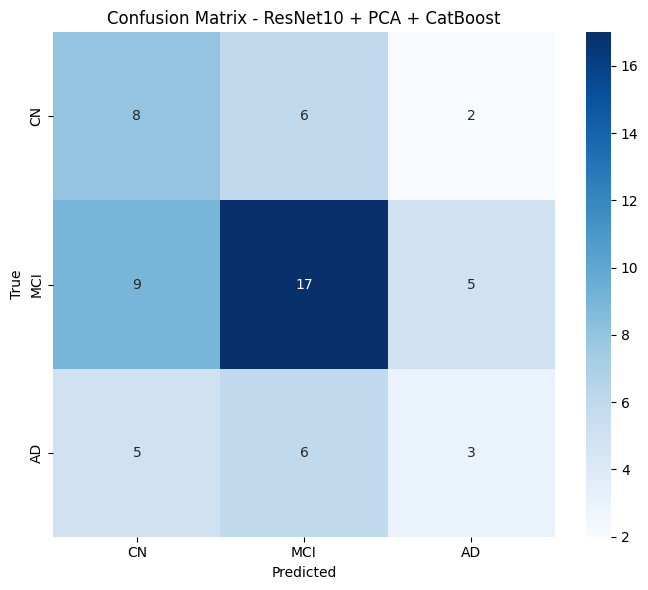


✅ Best iteration: 14
✅ Đã lưu model


In [ ]:

# CATBOOST VỚI EARLY STOPPING + REGULARIZATION
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

catboost = CatBoostClassifier(
    iterations        = 1000,
    learning_rate     = 0.01,   # nhỏ hơn
    depth             = 4,      # nông hơn, ít overfit
    l2_leaf_reg       = 10,     # regularization mạnh hơn
    loss_function     = 'MultiClass',
    eval_metric       = 'Accuracy',
    class_weights     = [3.97, 1.98, 4.13],
    early_stopping_rounds = 50, # dừng sớm nếu không cải thiện
    random_seed       = 42,
    verbose           = 100
)

catboost.fit(
    X_trainval_pca, y_trainval,
    eval_set=(X_test_pca, y_test)
)

# Đánh giá
y_pred = catboost.predict(X_test_pca)

print("\n" + "=" * 50)
print("KẾT QUẢ - ResNet10 + PCA + CatBoost")
print("=" * 50)
print(classification_report(y_test, y_pred,
                             target_names=['CN', 'MCI', 'AD']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN', 'MCI', 'AD'],
            yticklabels=['CN', 'MCI', 'AD'])
plt.title('Confusion Matrix - ResNet10 + PCA + CatBoost')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PBL4/confusion_matrix_pca_catboost.png', dpi=100)
plt.show()

catboost.save_model('/content/drive/MyDrive/PBL4/catboost_pca_model.cbm')
print(f"\n Best iteration: {catboost.best_iteration_}")
print(" Đã lưu model")
